# Companion Notebook — Aprendizado Não Supervisionado

**Disciplina:** GCC1734 — Inteligência Artificial  
**Tema:** Aprendizado de Máquina — Seção 8: Aprendizado Não Supervisionado  
**Objetivo:** transformar os conceitos da seção 8 em experimentos curtos com `k-means` e `PCA`.

Este notebook acompanha a seção **Aprendizado Não Supervisionado** das notas. Ele cobre:

1. o que muda quando não temos rótulos;
2. a intuição do `k-means`;
3. o exemplo resolvido das notas implementado em Python;
4. agrupamento em dados sintéticos com `scikit-learn`;
5. limitações do `k-means`;
6. escolha de `k` com cotovelo e silhueta;
7. a intuição geométrica do `PCA`;
8. redução de dimensionalidade e visualização;
9. uso de `PCA` antes de `k-means`.


## 0. Preparação do ambiente

Se necessário, instale as dependências do projeto:

```bash
pip install -r requirements.txt
```


In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from sklearn.cluster import KMeans
    from sklearn.datasets import load_wine, make_blobs, make_moons
    from sklearn.decomposition import PCA
    from sklearn.metrics import silhouette_score
    from sklearn.preprocessing import StandardScaler
except ImportError as exc:
    raise ImportError(
        "Este notebook requer scikit-learn. Instale as dependencias com `pip install -r requirements.txt`."
    ) from exc

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
def plot_points(X, y=None, centers=None, title=None, cmap="tab10"):
    plt.figure(figsize=(6, 5))
    if y is None:
        plt.scatter(X[:, 0], X[:, 1], s=45, edgecolor="k", alpha=0.85)
    else:
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, s=45, edgecolor="k", alpha=0.85)
    if centers is not None:
        plt.scatter(
            centers[:, 0],
            centers[:, 1],
            marker="*",
            s=350,
            c="gold",
            edgecolor="black",
            linewidth=1.2,
            label="centróides"
        )
        plt.legend()
    if title:
        plt.title(title)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.show()


def squared_distances(X, centers):
    return ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)


def kmeans_objective(X, centers, labels):
    return np.sum((X - centers[labels]) ** 2)


def principal_axes_from_pca(pca, scale=3.0):
    axes = []
    for length, vector in zip(np.sqrt(pca.explained_variance_), pca.components_):
        axes.append(scale * length * vector)
    return np.array(axes)


## 1. Quando não temos rótulos

No aprendizado supervisionado, cada exemplo vem com uma resposta desejada. No aprendizado não supervisionado, recebemos apenas as entradas e tentamos descobrir **estrutura** nos dados.

Duas tarefas centrais da seção 8 são:

- **agrupamento**: descobrir grupos parecidos, como no `k-means`;
- **redução de dimensionalidade**: comprimir os dados preservando o máximo possível de informação, como no `PCA`.


## 2. `k-means`: ideia central

O `k-means` busca `k` centróides e uma atribuição de cada ponto ao centróide mais próximo, minimizando a soma das distâncias quadráticas dentro dos grupos:

$$
J = \sum_{i=1}^{n} \left\| x^{(i)} - \mu_{c(i)} \right\|^2
$$

O algoritmo alterna dois passos:

1. **Passo E**: atribuir cada ponto ao centróide mais próximo.
2. **Passo M**: recalcular cada centróide como a média dos pontos do grupo.

Esse processo reduz `J` a cada iteração até convergir para um mínimo local.


### Exemplo resolvido das notas

Vamos reproduzir o exemplo da seção 8.2.1 usando o conjunto:

$$
\{(1,1), (1,2), (5,4), (5,5)\}
$$

com centróides iniciais

$$
\mu_1 = (1,1), \quad \mu_2 = (5,4).
$$


In [3]:
X_example = np.array([
    [1.0, 1.0],
    [1.0, 2.0],
    [5.0, 4.0],
    [5.0, 5.0],
])
centers_example = np.array([
    [1.0, 1.0],
    [5.0, 4.0],
])

d2 = squared_distances(X_example, centers_example)
labels_iter1 = np.argmin(d2, axis=1)
new_centers = np.vstack([
    X_example[labels_iter1 == cluster_id].mean(axis=0)
    for cluster_id in range(len(centers_example))
])

print("Distancias quadradas para cada ponto e centróide:")
print(d2)
print("\nAtribuicoes na iteracao 1:", labels_iter1)
print("Novos centroides apos o passo M:")
print(new_centers)
print("\nCusto J antes da atualizacao:", kmeans_objective(X_example, centers_example, labels_iter1))
print("Custo J apos a atualizacao:", kmeans_objective(X_example, new_centers, labels_iter1))


Distancias quadradas para cada ponto e centróide:
[[ 0. 25.]
 [ 1. 20.]
 [25.  0.]
 [32.  1.]]

Atribuicoes na iteracao 1: [0 0 1 1]
Novos centroides apos o passo M:
[[1.  1.5]
 [5.  4.5]]

Custo J antes da atualizacao: 2.0
Custo J apos a atualizacao: 1.0


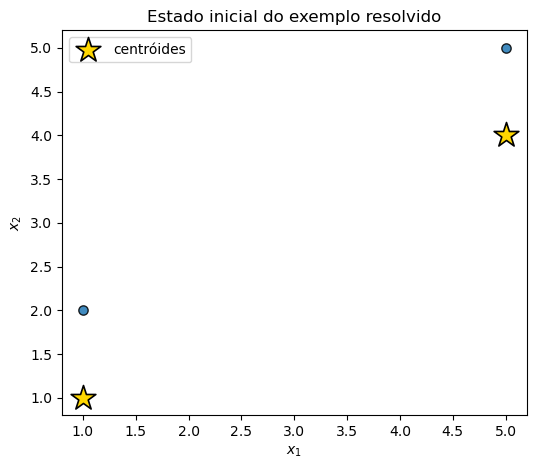

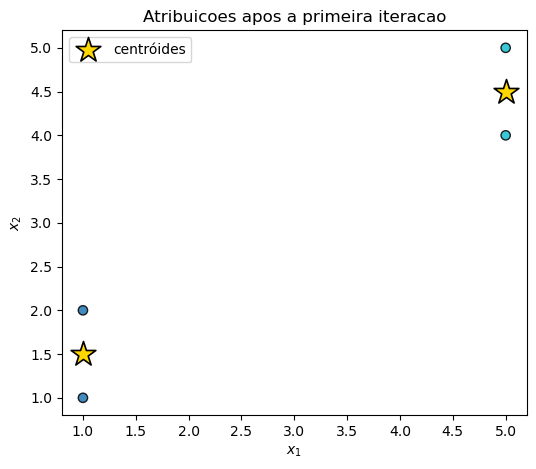

In [4]:
plot_points(X_example, centers=centers_example, title="Estado inicial do exemplo resolvido")
plot_points(X_example, y=labels_iter1, centers=new_centers, title="Atribuicoes apos a primeira iteracao")


O resultado coincide com as notas: os grupos naturais são `\{(1,1), (1,2)\}` e `\{(5,4), (5,5)\}`, e o algoritmo converge rapidamente.


### Agrupando dados sintéticos com `scikit-learn`

Agora vamos aplicar `k-means` a um conjunto com três grupos bem definidos.


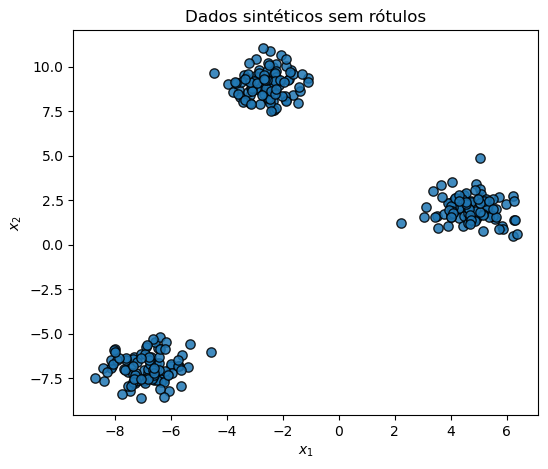

In [5]:
X_blobs, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.75,
    random_state=RANDOM_STATE
)

plot_points(X_blobs, title="Dados sintéticos sem rótulos")


In [6]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels_blobs = kmeans.fit_predict(X_blobs)

print("Centróides finais:")
print(kmeans.cluster_centers_)
print("\nInercia (soma das distancias quadradas):", kmeans.inertia_)


Centróides finais:
[[-2.60222391  9.03624887]
 [-6.88281064 -6.95801551]
 [ 4.72029724  2.00123813]]

Inercia (soma das distancias quadradas): 318.8584975074824


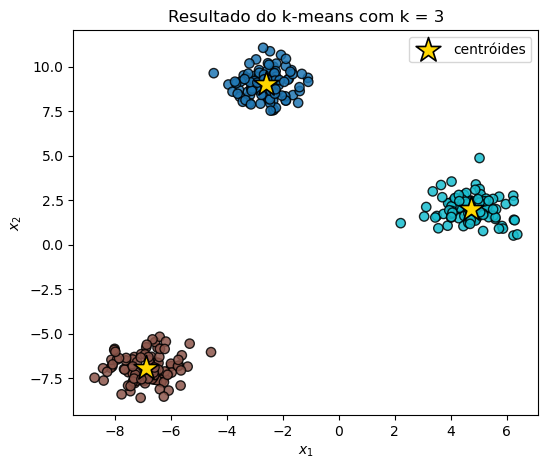

In [7]:
plot_points(
    X_blobs,
    y=labels_blobs,
    centers=kmeans.cluster_centers_,
    title="Resultado do k-means com k = 3"
)


## 3. Limitações do `k-means`

As notas destacam três limitações importantes:

- é preciso escolher `k` antes de treinar;
- o resultado depende da inicialização;
- o método funciona melhor quando os grupos são aproximadamente esféricos e com variância parecida.

O exemplo abaixo mostra o terceiro ponto.


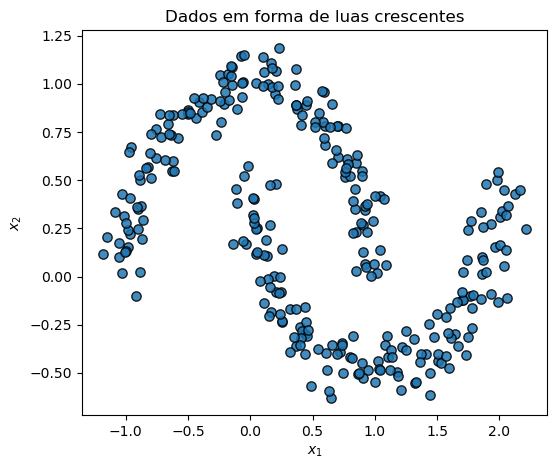

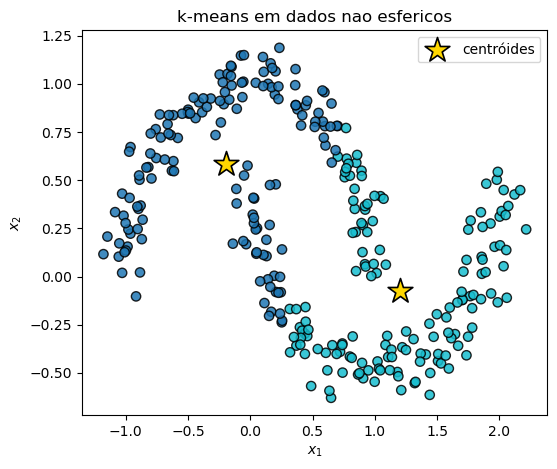

In [8]:
X_moons, _ = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
labels_moons = kmeans_moons.fit_predict(X_moons)

plot_points(X_moons, title="Dados em forma de luas crescentes")
plot_points(
    X_moons,
    y=labels_moons,
    centers=kmeans_moons.cluster_centers_,
    title="k-means em dados nao esfericos"
)


Mesmo com `k = 2`, o agrupamento não respeita bem a geometria natural das duas luas. Isso ilustra por que `k-means` pode falhar quando os grupos não são convexos ou esféricos.


### Como escolher `k`?

A seção 8 menciona que `k` precisa ser fornecido a priori. Na prática, duas heurísticas comuns são:

- **método do cotovelo**: procurar um ponto a partir do qual a redução da inércia passa a ser pequena;
- **silhueta**: medir quão coesos e separados os grupos ficaram.


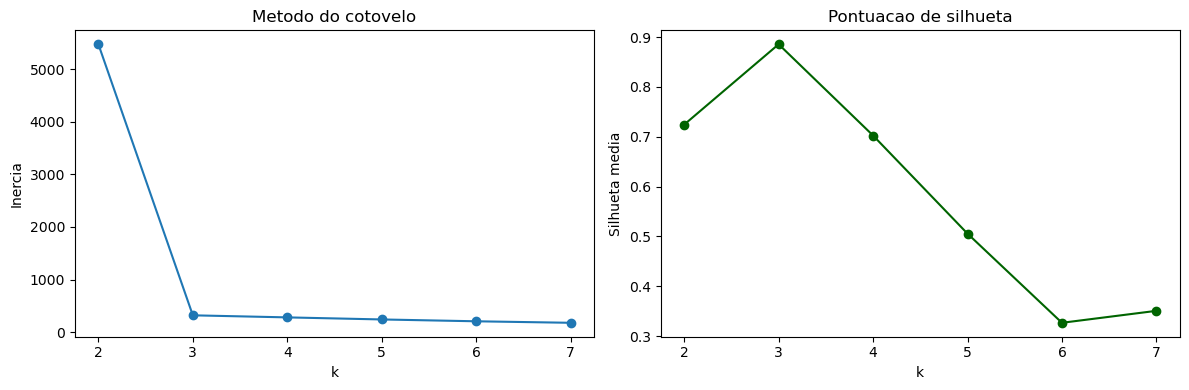

Melhor k pela silhueta: 3


In [9]:
k_values = range(2, 8)
inertias = []
silhouettes = []

for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_blobs)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_blobs, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_title("Metodo do cotovelo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")

axes[1].plot(list(k_values), silhouettes, marker="o", color="darkgreen")
axes[1].set_title("Pontuacao de silhueta")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhueta media")

plt.tight_layout()
plt.show()

best_k = list(k_values)[int(np.argmax(silhouettes))]
print("Melhor k pela silhueta:", best_k)


## 4. `PCA`: intuição geométrica

O `PCA` busca novas direções ortogonais no espaço de atributos:

- a **primeira componente principal** (`PC1`) aponta para a direção de maior variância;
- a **segunda componente** (`PC2`) captura a maior variância restante, sendo ortogonal a `PC1`;
- projetar os dados nas primeiras componentes reduz a dimensionalidade preservando o máximo possível da variância.


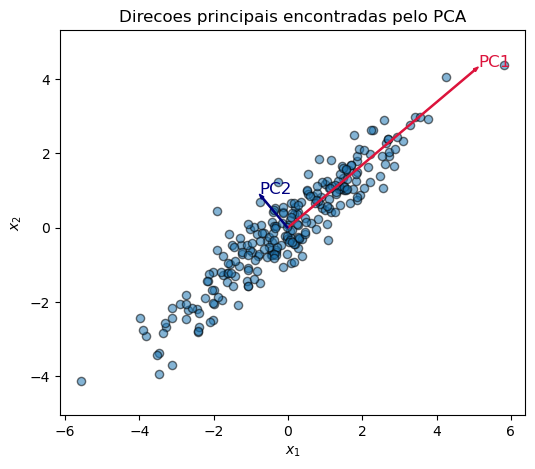

Variancia explicada por cada componente: [0.96983552 0.03016448]


In [10]:
mean = np.array([0.0, 0.0])
cov = np.array([[3.0, 2.4], [2.4, 2.2]])
X_corr = np.random.multivariate_normal(mean, cov, size=250)

pca_2d = PCA(n_components=2)
pca_2d.fit(X_corr)

origin = X_corr.mean(axis=0)
axes = principal_axes_from_pca(pca_2d)

plt.figure(figsize=(6, 5))
plt.scatter(X_corr[:, 0], X_corr[:, 1], alpha=0.55, edgecolor="k", s=35)
colors = ["crimson", "navy"]
labels = ["PC1", "PC2"]
for axis, color, label in zip(axes, colors, labels):
    plt.arrow(origin[0], origin[1], axis[0], axis[1], color=color, width=0.03, length_includes_head=True)
    plt.text(origin[0] + axis[0], origin[1] + axis[1], label, color=color, fontsize=12)
plt.title("Direcoes principais encontradas pelo PCA")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis("equal")
plt.show()

print("Variancia explicada por cada componente:", pca_2d.explained_variance_ratio_)


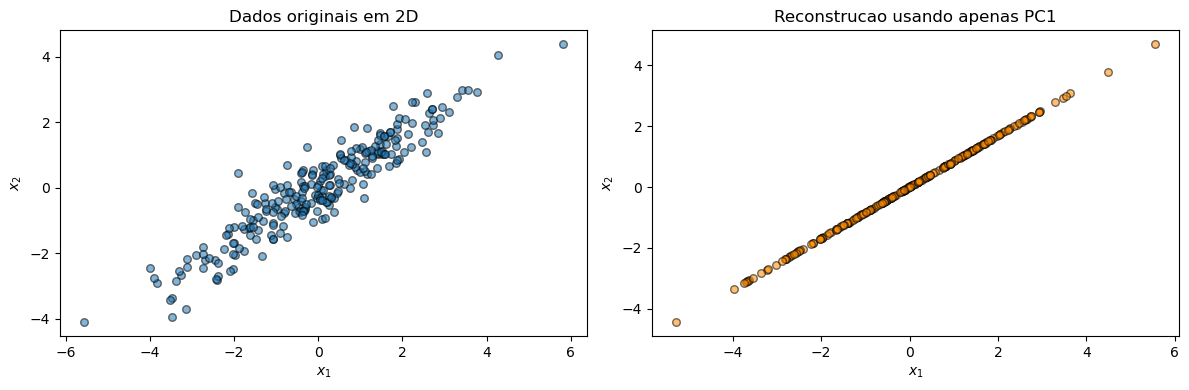

Forma original: (250, 2)
Forma apos projetar em 1D: (250, 1)
Variancia preservada: 0.9698355203093763


In [11]:
pca_1d = PCA(n_components=1)
X_corr_1d = pca_1d.fit_transform(X_corr)
X_reconstructed = pca_1d.inverse_transform(X_corr_1d)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_corr[:, 0], X_corr[:, 1], alpha=0.55, edgecolor="k", s=30)
axes[0].set_title("Dados originais em 2D")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")

axes[1].scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.55, edgecolor="k", s=30, color="darkorange")
axes[1].set_title("Reconstrucao usando apenas PC1")
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("$x_2$")

plt.tight_layout()
plt.show()

print("Forma original:", X_corr.shape)
print("Forma apos projetar em 1D:", X_corr_1d.shape)
print("Variancia preservada:", pca_1d.explained_variance_ratio_.sum())


## 5. `PCA` em um conjunto de maior dimensionalidade

O conjunto `wine` do `scikit-learn` possui 13 atributos numéricos. Vamos padronizar as variáveis e projetar os dados nas duas primeiras componentes principais.

Embora o `PCA` não use rótulos, podemos colorir os pontos pelas classes verdadeiras apenas para interpretar visualmente o resultado.


(178, 13)


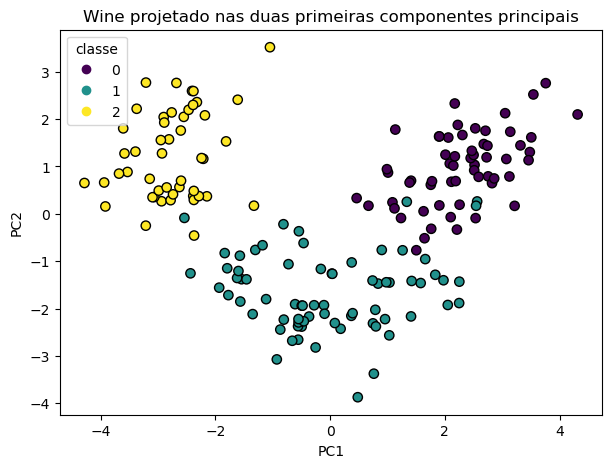

Variancia explicada por PC1 e PC2: [0.36198848 0.1920749 ]
Variancia acumulada: 0.5540633835693527


In [15]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print(X_wine.shape)

scaler = StandardScaler()

X_wine_scaled = scaler.fit_transform(X_wine)

pca_wine = PCA(n_components=2)
X_wine_2d = pca_wine.fit_transform(X_wine_scaled)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=y_wine, cmap="viridis", s=45, edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine projetado nas duas primeiras componentes principais")
plt.legend(*scatter.legend_elements(), title="classe")
plt.show()

print("Variancia explicada por PC1 e PC2:", pca_wine.explained_variance_ratio_)
print("Variancia acumulada:", pca_wine.explained_variance_ratio_.sum())


## 6. `PCA` antes de `k-means`

As notas sugerem que `PCA` pode ser útil antes de outro algoritmo de AM. Em clustering, isso pode ajudar quando há muitas dimensões correlacionadas ou ruidosas.

Aqui vamos comparar `k-means` no espaço original padronizado e no espaço reduzido para 2 dimensões por `PCA`.


In [13]:
kmeans_original = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels_original = kmeans_original.fit_predict(X_wine_scaled)
sil_original = silhouette_score(X_wine_scaled, labels_original)

kmeans_pca = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels_pca = kmeans_pca.fit_predict(X_wine_2d)
sil_pca = silhouette_score(X_wine_2d, labels_pca)

print(f"Silhueta no espaco original padronizado: {sil_original:.3f}")
print(f"Silhueta apos PCA para 2 dimensoes: {sil_pca:.3f}")


Silhueta no espaco original padronizado: 0.285
Silhueta apos PCA para 2 dimensoes: 0.561


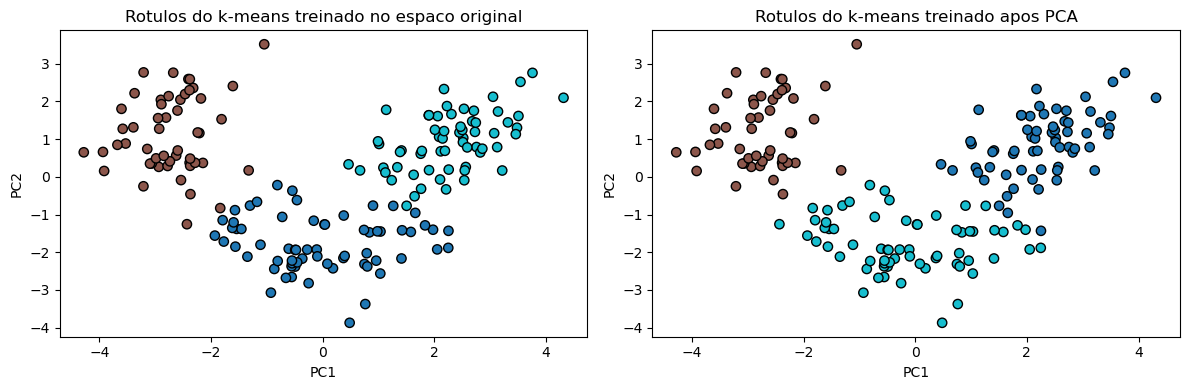

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=labels_original, cmap="tab10", s=45, edgecolor="k")
axes[0].set_title("Rotulos do k-means treinado no espaco original")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=labels_pca, cmap="tab10", s=45, edgecolor="k")
axes[1].set_title("Rotulos do k-means treinado apos PCA")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()


## 7. Conclusões

- `k-means` procura centróides que minimizam a variabilidade dentro dos grupos.
- O algoritmo converge porque cada passo não aumenta o custo `J`.
- A escolha de `k` e a inicialização importam.
- `PCA` encontra projeções lineares que preservam o máximo possível da variância.
- Em dados de alta dimensão, `PCA` pode facilitar visualização, compressão e até servir de pré-processamento para clustering.


## 8. Sugestões de estudo

1. Modifique o exemplo manual de `k-means` para `k = 3` usando os pontos da atividade 10.5 das notas.
2. Troque o conjunto `make_blobs` por outro com mais sobreposição e observe como a silhueta muda.
3. Aumente o número de componentes do `PCA` em `wine` e acompanhe a variância acumulada.
4. Compare o resultado de `k-means` com e sem padronização dos atributos.
